# Dates Analysis

In [134]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("insurance_claims.csv")
# drop column as 100% nan-values
df.drop('_c39', axis=1,inplace= True)
#ensure consistency on column names
rename ={'capital-gains':'capital_gains','capital-loss': 'capital_loss'}
df.rename(columns=rename, inplace=True)
#set index
df=df.set_index('policy_number')
#fraud_reported to binary
df['fraud_reported']=df['fraud_reported'].map({'Y':1,'N':0})
# sex to binary
df['insured_sex']=df['insured_sex'].map({'F':1,'M':0})




In [135]:
df.head(7)

,months_as_customer,age,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,insured_sex,...,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported
policy_number,,,,,,,,,,,,,,,,,,,,,
521585,328,48,2014-10-17,OH,250/500,1000,1406.91,0,466132,NaN,...,2,YES,71610,6510,13020,52080,Saab,92x,2004,1
342868,228,42,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,NaN,...,0,?,5070,780,780,3510,Mercedes,E400,2007,1
687698,134,29,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,NaN,...,3,NO,34650,7700,3850,23100,Dodge,RAM,2007,0
227811,256,41,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,NaN,...,2,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,1
367455,228,44,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,NaN,...,1,NO,6500,1300,650,4550,Accura,RSX,2009,0
104594,256,39,2006-10-12,OH,250/500,1000,1351.10,0,478456,NaN,...,2,NO,64100,6410,6410,51280,Saab,95,2003,1
413978,137,34,2000-06-04,IN,250/500,1000,1333.35,0,441716,NaN,...,0,?,78650,21450,7150,50050,Nissan,Pathfinder,2012,0


In [136]:
#change to datetime
df["policy_bind_date"]=pd.to_datetime(df['policy_bind_date'])
df["incident_date"]=pd.to_datetime(df['incident_date'])
df[['policy_bind_date', 'incident_date']].dtypes


#additional columns year, month, date of policy bind date
df['policy_bind_year']=df["policy_bind_date"].dt.year
df['policy_bind_month']=df["policy_bind_date"].dt.month
df['policy_bind_weekday']=df["policy_bind_date"].dt.weekday+1
#get week number from policy_bind_date
df['policy_bind_week']=df["policy_bind_date"].dt.isocalendar().week


#additional columns month, date of incident date as year is 2015 for all cases
df['incident_year']=df["incident_date"].dt.year
df['incident_month']=df["incident_date"].dt.month #to be reviewed to fraud_reported
df['incident_weekday']=df["incident_date"].dt.weekday+1 #to be reviewed to fraud_reported
#get week number from incident_date
df['incident_week']=df["incident_date"].dt.isocalendar().week

#subtract incident_date from policy_bind date to get policy duration
df['policy_duration_days']=df['incident_date']-df['policy_bind_date']
df['policy_duration_days']=df['policy_duration_days'].dt.days
df['policy_duration_days'].head() #in days

# policiy_duration_days to months
df['policy_duration_months']=df['policy_duration_days']//30

#age of car at incident date
df['age_of_auto']=df['incident_date'].dt.year-df['auto_year']
df['age_of_auto'].head()


df

,months_as_customer,age,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,insured_sex,...,policy_bind_month,policy_bind_weekday,policy_bind_week,incident_year,incident_month,incident_weekday,incident_week,policy_duration_days,policy_duration_months,age_of_auto
policy_number,,,,,,,,,,,,,,,,,,,,,
521585,328,48,2014-10-17,OH,250/500,1000,1406.91,0,466132,NaN,...,10,5,42,2015,1,7,4,100,3,11
342868,228,42,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,NaN,...,6,2,26,2015,1,3,4,3130,104,8
687698,134,29,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,NaN,...,9,3,36,2015,2,7,8,5282,176,8
227811,256,41,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,NaN,...,5,5,21,2015,1,6,2,8996,299,1
367455,228,44,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,NaN,...,6,5,23,2015,2,2,8,256,8,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
941851,3,38,1991-07-16,OH,500/1000,1000,1310.80,0,431289,NaN,...,7,2,29,2015,2,7,8,8622,287,9
186934,285,41,2014-01-05,IL,100/300,1000,1436.79,0,608177,NaN,...,1,7,1,2015,1,6,4,384,12,0
918516,130,34,2003-02-17,OH,250/500,500,1383.49,3000000,442797,NaN,...,2,1,8,2015,1,5,4,4358,145,19


In [ ]:
# P test and cramers v
dates = ['policy_bind_date', 'incident_date', 'policy_bind_year', 'policy_bind_month', 'policy_bind_weekday', 'incident_month', 'incident_weekday', \
         'policy_duration_days', 'policy_duration_months', 'months_as_customer', 'age_of_auto', 'policy_bind_week', 'incident_week', 'fraud_reported']

for i in dates:

    stat, p = chi2_contingency(pd.crosstab(df["fraud_reported"], df[i]))[:2]

    V_Cramer = np.sqrt(stat/pd.crosstab(df["fraud_reported"], df[i]).values.sum())

    print()
    print(i, ":\n Cramer's V : ",
          V_Cramer, " ; P-value : ", p, "\n")


policy_bind_date :
 Cramer's V :  0.9846484529765004  ; P-value :  0.3226352575740922 


incident_date :
 Cramer's V :  0.250495022207789  ; P-value :  0.34492209345532626 


policy_bind_year :
 Cramer's V :  0.1288204075026504  ; P-value :  0.8959657637579448 


policy_bind_month :
 Cramer's V :  0.13062260593656366  ; P-value :  0.10604723866076926 


policy_bind_weekday :
 Cramer's V :  0.08978469191410844  ; P-value :  0.23364729094489367 


incident_month :
 Cramer's V :  0.04374795890345583  ; P-value :  0.3840655821571572 


incident_weekday :
 Cramer's V :  0.07442433325051022  ; P-value :  0.4767578526080444 


policy_duration_days :
 Cramer's V :  0.9639543786491298  ; P-value :  0.695412565067642 


policy_duration_months :
 Cramer's V :  0.5107924607803908  ; P-value :  0.9044683534314282 


months_as_customer :
 Cramer's V :  0.6478311368709307  ; P-value :  0.14439148578952785 


age_of_auto :
 Cramer's V :  0.15298399040845864  ; P-value :  0.26939054879704044 


policy

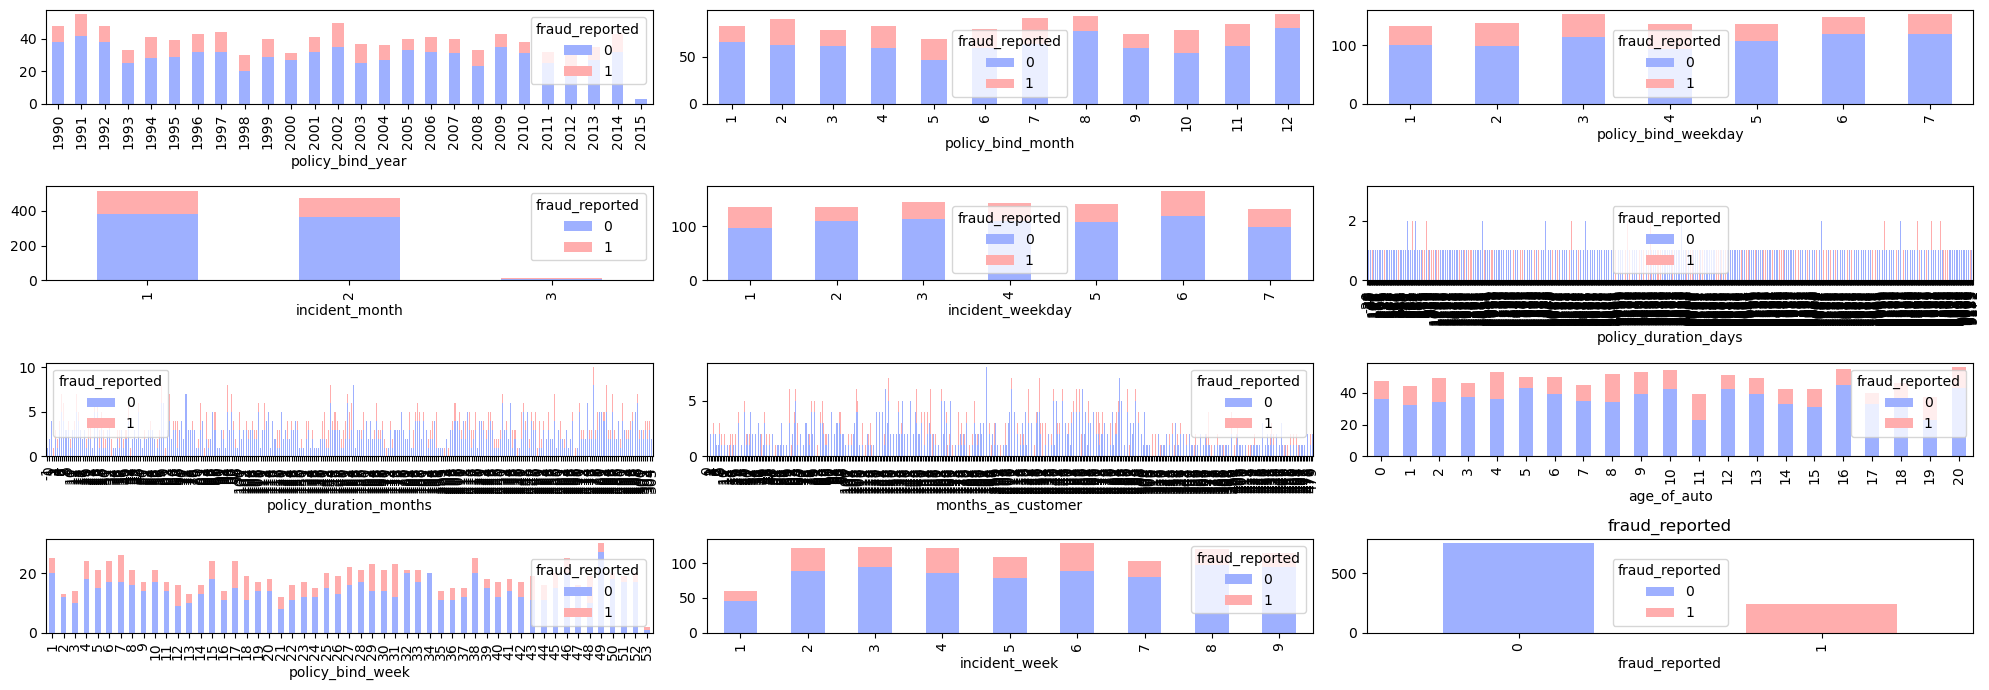

In [142]:
#plots
dates2 = ['policy_bind_year', 'policy_bind_month', 'policy_bind_weekday', 'incident_month', 'incident_weekday', \
         'policy_duration_days', 'policy_duration_months', 'months_as_customer', 'age_of_auto', 'policy_bind_week', 'incident_week', 'fraud_reported']

# plot dates to fraud_reported
fig, ax = plt.subplots(4, 3, figsize=(20, 7))
for variable, subplot in zip(dates2, ax.flatten()):
    pd.crosstab(df[variable], df['fraud_reported']).plot(kind='bar', stacked=True, ax=subplot, colormap='berlin')
    plt.title(variable)
plt.tight_layout()
plt.show()

In [143]:
#CONCLUSION: remove column as the months_as_customer for now makes no sense?

# new column policy_duration to years
df['policy_duration_years']=df['policy_duration_days']/365
df['policy_duration_years']=df['policy_duration_years'].astype(int)


# new column true/false where months_as_customer > policy_duration_months
df['customer_longer_than_policy']=df['months_as_customer']>df['policy_duration_months']
df['customer_longer_than_policy'].value_counts(normalize=True)

#cross tabulation of customer_longer_than_policy and fraud_reported
#pd.crosstab(df['customer_longer_than_policy'],df['fraud_reported'],normalize='index')




customer_longer_than_policy
True     0.612
False    0.388
Name: proportion, dtype: float64

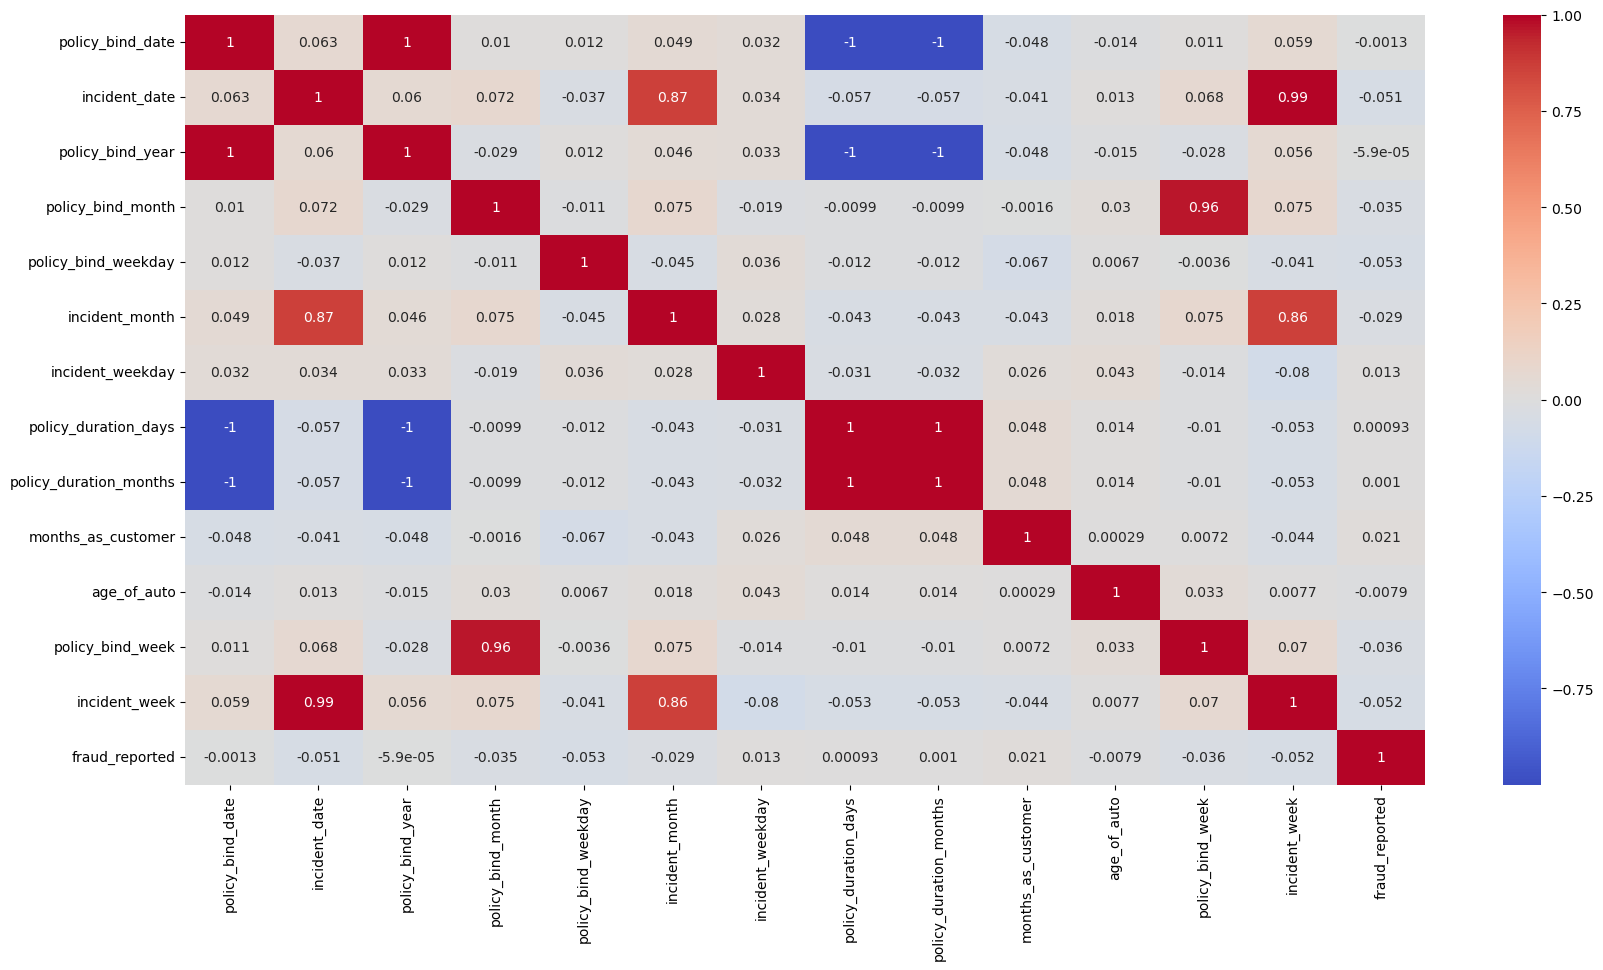

In [144]:
# heatmap of correlation
# Heatmap of correlation
plt.figure(figsize=(20, 10))

# Select only dates columns
df_dates = df[dates]

# Compute correlation matrix and plot heatmap
sns.heatmap(df_dates.corr(), annot=True, cmap='coolwarm')
plt.show()

In [145]:
df_dates.describe()

,policy_bind_date,incident_date,policy_bind_year,policy_bind_month,policy_bind_weekday,incident_month,incident_weekday,policy_duration_days,policy_duration_months,months_as_customer,age_of_auto,policy_bind_week,incident_week,fraud_reported
count,1000,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.0,1000.0,1000.000000
mean,2002-02-08 04:40:47.999999872,2015-01-30 08:02:24,2001.604000,6.559000,4.061000,1.496000,4.04700,4739.140000,157.501000,203.954000,9.897000,26.715,5.184,0.247000
min,1990-01-08 00:00:00,2015-01-01 00:00:00,1990.000000,1.000000,1.000000,1.000000,1.00000,-20.000000,-1.000000,0.000000,0.000000,1.0,1.0,0.000000
25%,1995-09-19 00:00:00,2015-01-15 00:00:00,1995.000000,3.000000,2.000000,1.000000,2.00000,2484.000000,82.000000,115.750000,5.000000,13.0,3.0,0.000000
50%,2002-04-01 12:00:00,2015-01-31 00:00:00,2002.000000,7.000000,4.000000,1.000000,4.00000,4682.000000,155.500000,199.500000,10.000000,27.0,5.0,0.000000
75%,2008-04-21 12:00:00,2015-02-15 00:00:00,2008.000000,10.000000,6.000000,2.000000,6.00000,7068.000000,235.000000,276.250000,15.000000,40.0,7.0,0.000000
max,2015-02-22 00:00:00,2015-03-01 00:00:00,2015.000000,12.000000,7.000000,3.000000,7.00000,9172.000000,305.000000,479.000000,20.000000,53.0,9.0,1.000000
std,NaN,NaN,7.360391,3.499824,2.004319,0.523697,1.97603,2686.430702,89.533459,115.113174,6.015861,15.293714,2.468651,0.431483


In [ ]:
# filter on policy_duration_days smaller than 0 --> DELETE?
df[df['policy_duration_days']<0]

,months_as_customer,age,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,insured_sex,...,policy_bind_week,incident_year,incident_month,incident_weekday,incident_week,policy_duration_days,policy_duration_months,age_of_auto,policy_duration_years,customer_longer_than_policy
policy_number,,,,,,,,,,,,,,,,,,,,,
794731,415,52,2015-02-22,IN,250/500,1000,973.5,0,468634,NaN,...,8,2015,2,1,6,-20,-1,12,0,True
